# need to make threads to be 8 ..

In [1]:
using Base
ENV["JULIA_NUM_THREADS"] = "auto"
Threads.nthreads()

1

In [2]:

using Pkg

cd(@__DIR__)

Pkg.activate("../")
ParamFile = "../config/testparam.csv" # 1D Earth/Mars/Moon models are defined

include("../src/commonBatchs.jl")
include("../src/planet1D.jl")
include("../src/GeoPoints.jl")

using .commonBatchs, .planet1D, .GeoPoints
using Colors



  Activating project at `~/Documents/Github/flexOPT`


In [3]:
using Statistics

In [4]:
using GLMakie
GLMakie.activate!()
Makie.inline!()

MakieCore.Automatic()

In [5]:
p0 = GeoPoint(35.363602,138.726379) # summit of Mt Fuji


GeoPoint(35.363602, 138.726379, 0.0, [-3.9135527429451863e6, 3.4349489523064685e6, 3.670837394580353e6], 6.3710137775878785e6)

In [6]:


Δx = 300.0 # in metre
Δy = 300.0
Δz = 100.0

altMax = 4.e3 # in metre
altMin = -10.e0 # in metre

horizontalDepth = 20.e3 

20000.0

In [7]:
boxGrids3D=constructLocalBox(p0,Δx,Δy,Δz,-horizontalDepth,horizontalDepth,-horizontalDepth,horizontalDepth,altMin,altMax)

p1 = GeoPoint(p1.lat, p1.lon) = GeoPoint(35.363392537059966, 138.50631581826323, 0.0, [-3.900340938644034e6, 3.449963769802205e6, 3.670818442978575e6], 6.371013851179584e6)
p2 = GeoPoint(p2.lat, p2.lon) = GeoPoint(35.363410746009556, 138.9464423292559, 0.0, [-3.926726158951646e6, 3.4199004293086603e6, 3.670820090473662e6], 6.371013844782146e6)


(allGridsInGeoPoints = GeoPoint[GeoPoint(35.18333316223508, 138.72639009013935, -41.87157463455304, [-3.9222080029676766e6, 3.4425443824367253e6, 3.6544851465673284e6], 6.371035169426674e6) GeoPoint(35.18603724792247, 138.72638992414906, -41.85836718237584, [-3.9220780819261293e6, 3.4424303701118734e6, 3.6547303438608395e6], 6.371034234732308e6) … GeoPoint(35.540257336934545, 138.7263680839373, 82.28309987773636, [-3.905058425483427e6, 3.427494755556268e6, 3.686851189310777e6], 6.371033926916974e6) GeoPoint(35.542961156185996, 138.72636791648597, 84.16514489889346, [-3.9049285044418797e6, 3.427380743231416e6, 3.687096386604288e6], 6.371034856911915e6); GeoPoint(35.18333325372368, 138.72968377142982, -41.86447951971806, [-3.922405893120666e6, 3.4423189063022975e6, 3.654485158951248e6], 6.371035176489681e6) GeoPoint(35.186037339411044, 138.7296837145362, -41.851272066453205, [-3.9222759720791187e6, 3.4422048939774456e6, 3.654730356244759e6], 6.371034241795315e6) … GeoPoint(35.54025742842

In [8]:
earthquakePoints = [GeoPoint(35.35,138.71),GeoPoint(35.36,138.72)]
stationPoints    = [GeoPoint(35.351,138.712),GeoPoint(35.361,138.721,alt=-3.e3)]  # array of GeoPoint


2-element Vector{GeoPoint}:
 GeoPoint(35.351, 138.712, 0.0, [-3.913298523275052e6, 3.4364648568486474e6, 3.6696971156907133e6], 6.371018204771608e6)
 GeoPoint(35.361, 138.721, -3000.0, [-3.911517197228428e6, 3.4338125063347584e6, 3.6688657910997155e6], 6.368014706796496e6)

In [9]:

extraPointSets = [
    GeoPointSet("earthquakes", earthquakePoints; color=:red, marker=:star5),
    GeoPointSet("stations", stationPoints; color=:blue, marker=:utriangle),
]

2-element Vector{GeoPointSet}:
 GeoPointSet("earthquakes", GeoPoint[GeoPoint(35.35, 138.71, 0.0, [-3.91322679769614e6, 3.4366438126280764e6, 3.669606624210372e6], 6.371018556049784e6), GeoPoint(35.36, 138.72, 0.0, [-3.913344097320077e6, 3.435537230498888e6, 3.670511489269142e6], 6.371015043070503e6)], :red, :star5)
 GeoPointSet("stations", GeoPoint[GeoPoint(35.351, 138.712, 0.0, [-3.913298523275052e6, 3.4364648568486474e6, 3.6696971156907133e6], 6.371018204771608e6), GeoPoint(35.361, 138.721, -3000.0, [-3.911517197228428e6, 3.4338125063347584e6, 3.6688657910997155e6], 6.368014706796496e6)], :blue, :utriangle)

In [10]:
eqLocal = [
    p_ECEF_to_local(p.ecef, p0.ecef, boxGrids3D.rotationMatrix)
    for p in earthquakePoints
]

staLocal = [
    p_ECEF_to_local(p.ecef, p0.ecef, boxGrids3D.rotationMatrix)
    for p in stationPoints
]

2-element Vector{SVector{3, Float64}}:
 [-1307.073289566552, -1397.9887145638634, 4.139745574413773]
 [-488.65808265725735, -298.0092346245262, -2999.096509087992]

In [11]:
eqLocal = GeoPoints_to_local(earthquakePoints, boxGrids3D)
staLocal = GeoPoints_to_local(stationPoints, boxGrids3D)

2-element Vector{SVector{3, Float64}}:
 [-1307.073289566552, -1397.9887145638634, 4.139745574413773]
 [-488.65808265725735, -298.0092346245262, -2999.096509087992]

In [13]:
seismicModel3D=lazyProduceOrLoad("seismicModel3D_Fuji",getParamsAndTopo,boxGrids3D.allGridsInGeoPoints,boxGrids3D.effectiveRadii,0.5)

Computing seismicModel3D_Fuji


┌ Info: File /Users/nobuaki/Documents/Github/flexOPT/data/topoViaGMT/topoViaGMT_ef1ead1d.jld2 does not exist. Producing it now...
└ @ DrWatson /Users/nobuaki/.julia/packages/DrWatson/2QF5p/src/saving_files.jl:106
┌ Warning: The Git repository ('/Users/nobuaki/Documents/Github/flexOPT') is dirty! Appending -dirty to the commit ID.
└ @ DrWatson /Users/nobuaki/.julia/packages/DrWatson/2QF5p/src/saving_tools.jl:71
┌ Info: File /Users/nobuaki/Documents/Github/flexOPT/data/topoViaGMT/topoViaGMT_ef1ead1d.jld2 saved.
└ @ DrWatson /Users/nobuaki/.julia/packages/DrWatson/2QF5p/src/saving_files.jl:115


(ρ = [2.6 2.6 … 2.6 2.6; 2.6 2.6 … 2.6 2.6; … ; 0.0 0.0 … 2.6 2.6; 0.0 0.0 … 2.6 2.6;;; 2.6 2.6 … 2.6 2.6; 2.6 2.6 … 2.6 2.6; … ; 0.0 0.0 … 2.6 2.6; 0.0 0.0 … 2.6 2.6;;; 0.0 0.0 … 2.6 2.6; 0.0 2.6 … 2.6 2.6; … ; 0.0 0.0 … 2.6 2.6; 0.0 0.0 … 2.6 2.6;;; … ;;; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0;;; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0;;; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], Vpv = [5.8 5.8 … 5.8 5.8; 5.8 5.8 … 5.8 5.8; … ; 0.0 0.0 … 5.8 5.8; 0.0 0.0 … 5.8 5.8;;; 5.8 5.8 … 5.8 5.8; 5.8 5.8 … 5.8 5.8; … ; 0.0 0.0 … 5.8 5.8; 0.0 0.0 … 5.8 5.8;;; 0.0 0.0 … 5.8 5.8; 0.0 5.8 … 5.8 5.8; … ; 0.0 0.0 … 5.8 5.8; 0.0 0.0 … 5.8 5.8;;; … ;;; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0;;; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0;;; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0

In [14]:
Nx3D,Ny3D,Nz3D=boxGrids3D.Nx, boxGrids3D.Ny, boxGrids3D.Nz

(134, 134, 41)

In [15]:
boxGrids3D.allGridsInGeoPoints[1,1,1]

GeoPoint(35.18333316223508, 138.72639009013935, -41.87157463455304, [-3.9222080029676766e6, 3.4425443824367253e6, 3.6544851465673284e6], 6.371035169426674e6)

In [16]:


x = [p.xyz[1] for p in boxGrids3D.allGridsInCartesian[:,1,1]]*1.e-3
y = [p.xyz[2] for p in boxGrids3D.allGridsInCartesian[1,:,1]]*1.e-3
z = [p.xyz[3] for p in boxGrids3D.allGridsInCartesian[1,1,:]]*1.e-3


ρ = seismicModel3D.ρ

sx = max(1, ceil(Int, size(ρ, 1) / 512))
sy = max(1, ceil(Int, size(ρ, 2) / 512))
sz = max(1, ceil(Int, size(ρ, 3) / 256))

ρ_plot = ρ[1:sx:end, 1:sy:end, 1:sz:end]
xg = x[1:sx:end]
yg = y[1:sy:end]
zg = z[1:sz:end]

println("original size = ", size(ρ))
println("plot size = ", size(ρ_plot))
println("strides = ", (sx, sy, sz))


original size = (134, 134, 41)
plot size = (134, 134, 41)
strides = (1, 1, 1)


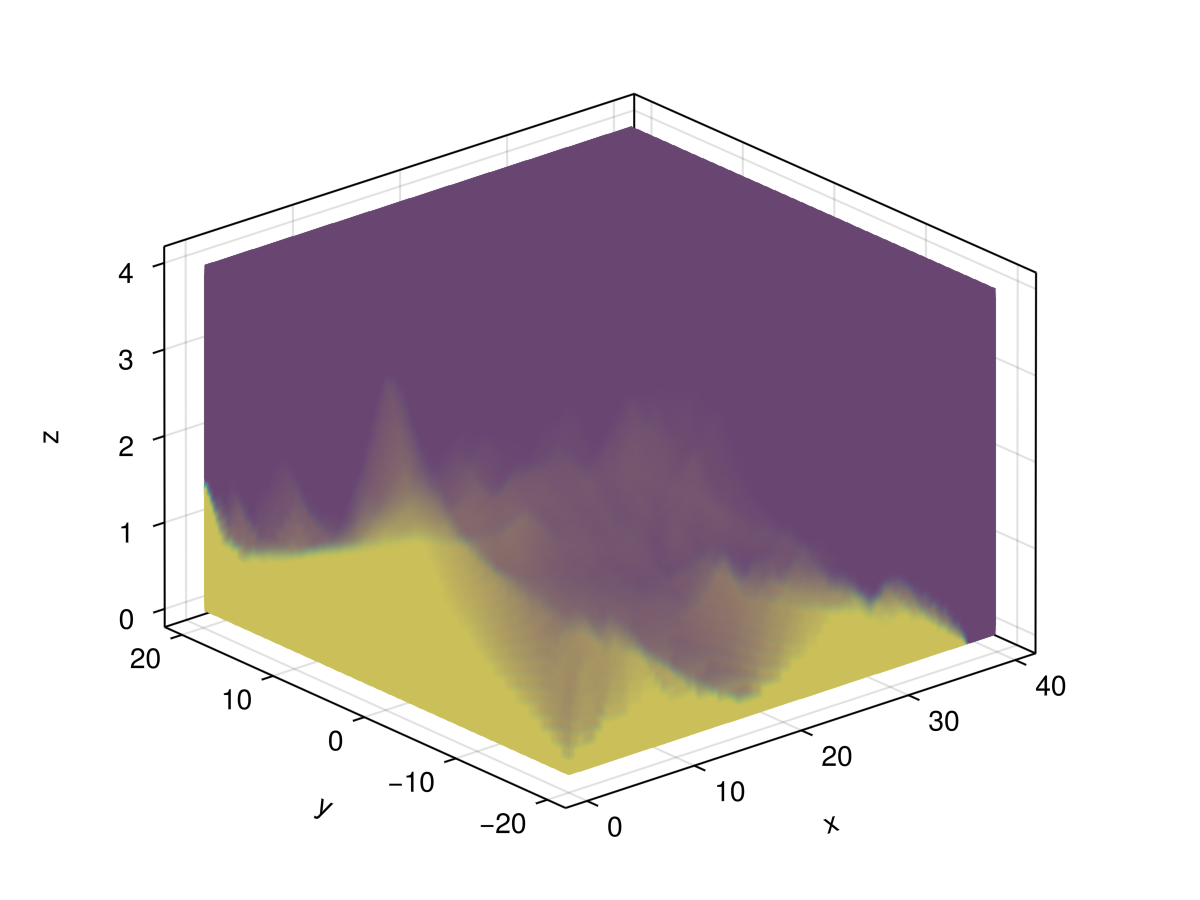

In [17]:




f = Figure()
ax = Axis3(f[1, 1])

volume!(
    ax,
    xg[1] .. xg[end],
    yg[1] .. yg[end],
    zg[1] .. zg[end],
    ρ_plot;
    algorithm = :absorption,
    colormap = :viridis,
)
f

# finding vertical gradient of Vpv

In [ ]:
Vp = seismicModel3D.Vpv

# Vertical Vp gradient, same size as Vp
dVp_dz = similar(Vp)

for k in 2:length(z)-1
    dVp_dz[:, :, k] .= (Vp[:, :, k+1] .- Vp[:, :, k-1]) ./ (z[k+1] - z[k-1])
end

dVp_dz[:, :, 1] .= (Vp[:, :, 2] .- Vp[:, :, 1]) ./ (z[2] - z[1])
dVp_dz[:, :, end] .= (Vp[:, :, end] .- Vp[:, :, end-1]) ./ (z[end] - z[end-1])
Gg = dVp_dz[1:sx:end, 1:sy:end, 1:sz:end];

In [ ]:
valid = filter(isfinite, vec(abs.(Gg)))
thr = quantile(valid, 0.98)   # strongest 2%
println("threshold = ", thr)

In [ ]:
f = Figure()
ax = Axis3(f[1, 1];
    xlabel = "x [km]",
    ylabel = "y [km]",
    zlabel = "z [km]",
)
contour!(
    ax,
    xg[1] .. xg[end],
    yg[1] .. yg[end],
    zg[1] .. zg[end],
    Gg;
    levels = [thr],
    color = (:red, 0.45),
    transparency = true,
)
contour!(
    ax,
    xg[1] .. xg[end],
    yg[1] .. yg[end],
    zg[1] .. zg[end],
    Gg;
    levels = [-thr],
    color = (:blue, 0.45),
    transparency = true,
)
f

In [ ]:
zTopo = Matrix{Float64}(undef, length(x), length(y))
changeStrength = Matrix{Float64}(undef, length(x), length(y))

for i in eachindex(x), j in eachindex(y)
    col = abs.(dVp_dz[i, j, :])
    kmax = argmax(col)

    zTopo[i, j] = z[kmax]
    changeStrength[i, j] = col[kmax]
end

In [ ]:
s = 20  # try 10, 20, 50

x2 = x[1:s:end]
y2 = y[1:s:end]
z2 = zTopo[1:s:end, 1:s:end]
c2 = changeStrength[1:s:end, 1:s:end]

f = Figure()
ax = Axis3(f[1, 1])
f = Figure()
ax = Axis3(f[1, 1])

volume!(ax,
    x2,
    y2,
    z2,
    c2,
    algorithm = :absorption,   # optional, makes it nicer
    colormap = :viridis
)

In [ ]:
display(f)

In [ ]:
println("zTopo size = ", size(zTopo))
println("changeStrength min/max = ", extrema(changeStrength))
println("zTopo min/max = ", extrema(zTopo))
println("finite masked points = ", count(isfinite, zTopoMasked), " / ", length(zTopoMasked))

In [ ]:
scatter!(
    first.(eqLocal),
    getindex.(eqLocal, 2),
    getindex.(eqLocal, 3);
    label="earthquakes",
    marker=:star5,
    color=:red,
)

scatter!(
    first.(staLocal),
    getindex.(staLocal, 2),
    getindex.(staLocal, 3);
    label="stations",
    marker=:utriangle,
    color=:blue,
)